In [93]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [95]:
df=pd.read_csv('adult_with_headers.csv')

In [97]:
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [99]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

In [101]:
from sklearn.preprocessing import StandardScaler

In [103]:
scalar=StandardScaler()

In [105]:
df.dtypes

age                int64
workclass         object
fnlwgt             int64
education         object
education_num      int64
marital_status    object
occupation        object
relationship      object
race              object
sex               object
capital_gain       int64
capital_loss       int64
hours_per_week     int64
native_country    object
income            object
dtype: object

In [107]:
numeric = df.select_dtypes(include=['int64', 'float64'])
display(numeric.head())

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
0,39,77516,13,2174,0,40
1,50,83311,13,0,0,13
2,38,215646,9,0,0,40
3,53,234721,7,0,0,40
4,28,338409,13,0,0,40


In [109]:
from sklearn.preprocessing import MinMaxScaler
minmax_scalar = MinMaxScaler()
scaled_data_minmax = minmax_scalar.fit_transform(numeric)
scaled_df_minmax = pd.DataFrame(scaled_data_minmax, columns=numeric.columns)
display(scaled_df_minmax.head())

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
0,0.301370,0.044302,0.800000,0.02174,0.0,0.397959
1,0.452055,0.048238,0.800000,0.00000,0.0,0.122449
2,0.287671,0.138113,0.533333,0.00000,0.0,0.397959
3,0.493151,0.151068,0.400000,0.00000,0.0,0.397959
4,0.150685,0.221488,0.800000,0.00000,0.0,0.397959


In [111]:
scaled_data_standard = scalar.fit_transform(numeric)
scaled_df_standard = pd.DataFrame(scaled_data_standard, columns=numeric.columns)
display(scaled_df_standard.head())

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
0,0.030671,-1.063611,1.134739,0.148453,-0.21666,-0.035429
1,0.837109,-1.008707,1.134739,-0.145920,-0.21666,-2.222153
2,-0.042642,0.245079,-0.420060,-0.145920,-0.21666,-0.035429
3,1.057047,0.425801,-1.197459,-0.145920,-0.21666,-0.035429
4,-0.775768,1.408176,1.134739,-0.145920,-0.21666,-0.035429


## Scenarios where each scaling technique is preferred and why. 

**Standardization (Z-score Scaling)**

*Preferred When:*

- Data follows a normal (Gaussian) distribution.
- Features have different means and standard deviations.
- Algorithms assume data is centered around zero, such as:
    - Linear Regression
    - Logistic Regression
    - Support Vector Machines (SVM)
    - Principal Component Analysis (PCA)
    - K-Means Clustering

Standardization keeps outliers but brings features to a comparable scale centered at 0 with unit variance.

**Min-Max Scaling (Normalization)**

*Preferred when:*

- You want features in a fixed range [0, 1] (or sometimes [-1, 1]).
- Algorithms that use distance metrics like Euclidean distance:
   - K-Nearest Neighbors (KNN)
   - Neural Networks
   - Gradient Descent–based models

Normalization ensures all features contribute equally to distance-based calculations and prevents dominance of features with large values.

In [114]:
categorical = df.select_dtypes(include=['object'])
display(categorical.head())

,workclass,education,marital_status,occupation,relationship,race,sex,native_country,income
0,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,United-States,<=50K
1,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,United-States,<=50K
2,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,United-States,<=50K
3,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,United-States,<=50K
4,Private,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Black,Female,Cuba,<=50K


In [116]:
from sklearn.preprocessing import LabelEncoder

# Categorical columns with less than 5 unique values
categorical_less_than_5 = [col for col in categorical.columns if categorical[col].nunique() < 5]

# Categorical columns with 5 or more unique values
categorical_more_than_5 = [col for col in categorical.columns if categorical[col].nunique() >= 5]

display("Categorical columns with less than 5 unique values:", categorical_less_than_5)
display("Categorical columns with 5 or more unique values:", categorical_more_than_5)

# Apply One-Hot Encoding
one_hot_encoded = pd.get_dummies(categorical[categorical_less_than_5])
display("One-Hot Encoded Data:", one_hot_encoded.head())

# Apply Label Encoding
label_encoded = categorical[categorical_more_than_5].apply(LabelEncoder().fit_transform)
display("Label Encoded Data:", label_encoded.head())

'Categorical columns with less than 5 unique values:'

['sex', 'income']

'Categorical columns with 5 or more unique values:'

['workclass',
 'education',
 'marital_status',
 'occupation',
 'relationship',
 'race',
 'native_country']

'One-Hot Encoded Data:'

,sex_ Female,sex_ Male,income_ <=50K,income_ >50K
0,0,1,1,0
1,0,1,1,0
2,0,1,1,0
3,0,1,1,0
4,1,0,1,0


'Label Encoded Data:'

,workclass,education,marital_status,occupation,relationship,race,native_country
0,7,9,4,1,1,4,39
1,6,9,2,4,0,4,39
2,4,11,0,6,1,4,39
3,4,1,2,6,0,2,39
4,4,9,2,10,5,2,5


## One-Hot Encoding

**Pros:**
- Avoids introducing ordinal relationships between categories that don't exist.
- Suitable for nominal categorical variables (no inherent order).
- Many machine learning algorithms perform better with one-hot encoded data.
**Cons:**
- Can lead to a high-dimensional feature space, especially with many unique categories.
- Increased memory usage and computational cost.

## Label Encoding

**Pros:**
- Reduces the dimensionality of the feature space.
- More memory efficient than one-hot encoding.
**Cons:**
- Introduces an artificial ordinal relationship between categories.
- Can negatively impact the performance of some machine learning algorithms, especially those that assume no order between categories.
  

In [119]:
# New feature 'hours_per_week_cat' by categorizing 'hours_per_week'
def categorize_hours(hours):
    if hours < 40:
        return 'Part-time'
    elif hours == 40:
        return 'Full-time'
    else:
        return 'Overtime'

df['hours_per_week_cat'] = df['hours_per_week'].apply(categorize_hours)

# New feature 'capital_gain_loss_ratio'
df['capital_gain_loss_ratio'] = (df['capital_gain'] - df['capital_loss']) / (df['capital_gain'] + df['capital_loss'] + 1e-6)

display(df[['hours_per_week', 'hours_per_week_cat', 'capital_gain', 'capital_loss', 'capital_gain_loss_ratio']].head())

,hours_per_week,hours_per_week_cat,capital_gain,capital_loss,capital_gain_loss_ratio
0,40,Full-time,2174,0,1.0
1,13,Part-time,0,0,0.0
2,40,Full-time,0,0,0.0
3,40,Full-time,0,0,0.0
4,40,Full-time,0,0,0.0


## 1. Feature: hours_per_week_cat

*Description:*
This feature categorizes the numerical variable hours_per_week into three groups — Part-time, Full-time, and Overtime.

*Rationale:*
- The number of hours worked per week often reflects employment type and income potential.
- Instead of treating it as a raw number, grouping helps the model understand non-linear patterns (e.g., working slightly more than 40 hours may not linearly increase income).
- It also improves interpretability and helps detect differences in income distribution across categories.

## 2. Feature: capital_gain_loss_ratio

*Description:*
- This feature measures the balance between capital gains and losses

*Rationale:*
- Captures an individual’s financial investment behavior more effectively than separate gain/loss columns.
- A higher ratio indicates profitable investments, which may correlate with higher income levels.
- It reduces redundancy and highlights net capital efficiency, making it more informative for classification or regression tasks.

In [122]:
# Skewed numerical features
skewness = numeric.skew()
display("Skewness of numerical features:", skewness)

# Skewness above a certain threshold (e.g., 0.5)
skewed_features = skewness[abs(skewness) > 0.5].index
display("Skewed numerical features:", skewed_features)

'Skewness of numerical features:'

age                0.558743
fnlwgt             1.446980
education_num     -0.311676
capital_gain      11.953848
capital_loss       4.594629
hours_per_week     0.227643
dtype: float64

'Skewed numerical features:'

Index(['age', 'fnlwgt', 'capital_gain', 'capital_loss'], dtype='object')

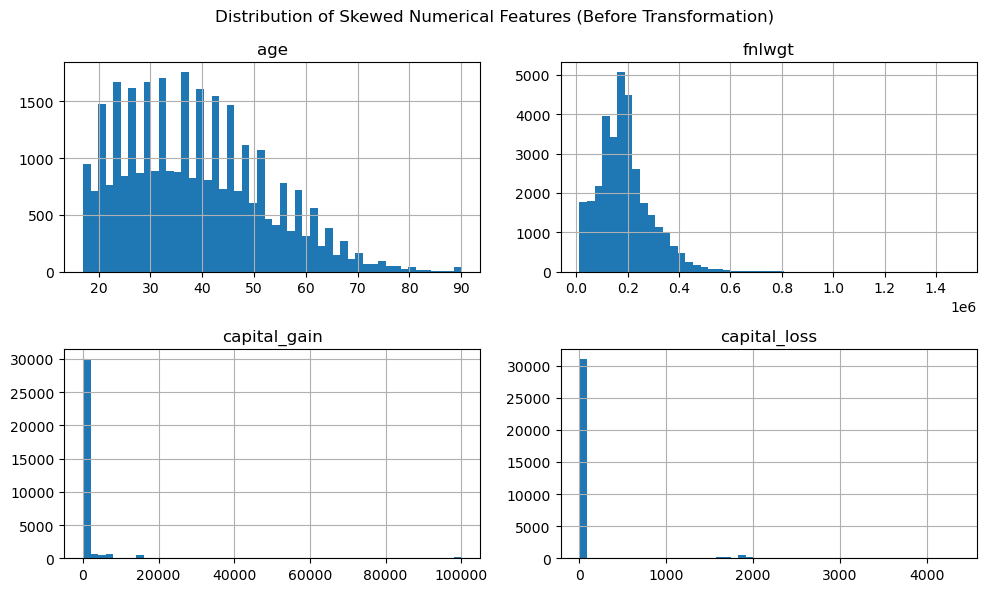

In [124]:
numeric[skewed_features].hist(bins=50, figsize=(10, 6))
plt.suptitle("Distribution of Skewed Numerical Features (Before Transformation)")
plt.tight_layout()
plt.show()

In [125]:
import numpy as np
for feature in skewed_features:
    df[feature + '_log'] = np.log1p(df[feature])

display("DataFrame with log-transformed features:", df.head())

'DataFrame with log-transformed features:'

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,...,capital_loss,hours_per_week,native_country,income,hours_per_week_cat,capital_gain_loss_ratio,age_log,fnlwgt_log,capital_gain_log,capital_loss_log
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,...,0,40,United-States,<=50K,Full-time,1.0,3.688879,11.258253,7.684784,0.0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,...,0,13,United-States,<=50K,Part-time,0.0,3.931826,11.330348,0.000000,0.0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,...,0,40,United-States,<=50K,Full-time,0.0,3.663562,12.281398,0.000000,0.0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,...,0,40,United-States,<=50K,Full-time,0.0,3.988984,12.366157,0.000000,0.0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,...,0,40,Cuba,<=50K,Full-time,0.0,3.367296,12.732013,0.000000,0.0


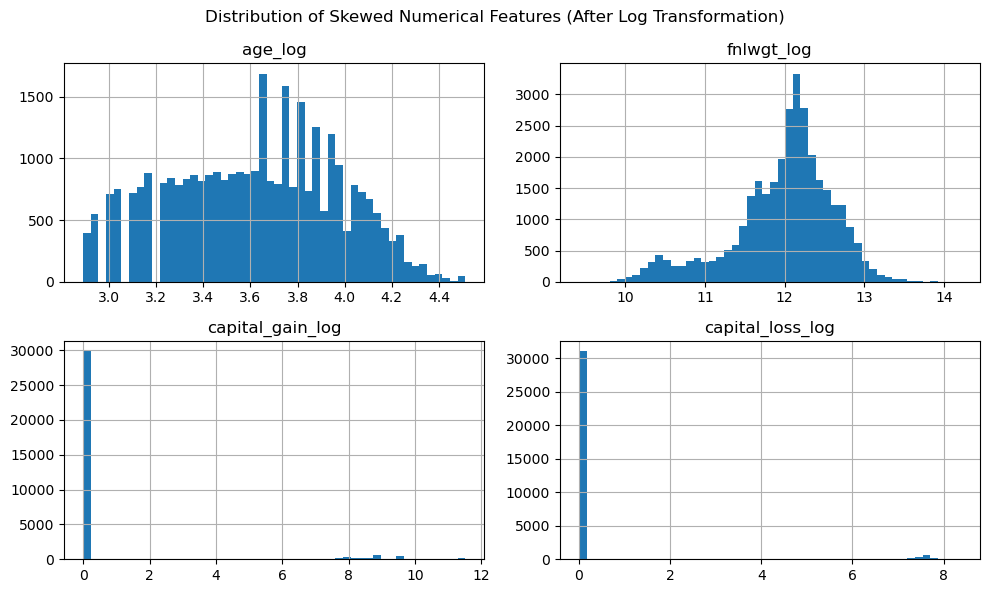

In [126]:
# Transformed features after transformation
df[[feature + '_log' for feature in skewed_features]].hist(bins=50, figsize=(10, 6))
plt.suptitle("Distribution of Skewed Numerical Features (After Log Transformation)")
plt.tight_layout()
plt.show()

## Justification

- In the given code, skewness of all numerical features is calculated to identify those that are highly skewed (|skewness| > 0.5).
-  Skewed features can negatively impact model performance because many algorithms assume that data is normally distributed.
-  To correct this, a log transformation can be applied to reduce the skewness of these features.
-  The log transformation compresses large values and spreads smaller ones, making the distribution more symmetric.
-   This helps:
    - Reduce the influence of extreme values (outliers).
    - Stabilize variance across the data.
    - Improve the performance and accuracy of models that are sensitive to feature distribution (like Linear Regression, Logistic Regression, or SVM).

In [128]:
from sklearn.ensemble import IsolationForest
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
iso = IsolationForest(contamination=0.1, random_state=42)
yhat = iso.fit_predict(df[numerical_features])

mask = yhat != -1
df_no_outliers = df[mask]

display("Original DataFrame shape:", df.shape)
display("DataFrame shape after removing outliers:", df_no_outliers.shape)

'Original DataFrame shape:'

(32561, 21)

'DataFrame shape after removing outliers:'

(29305, 21)

## How Outliers Affect Model Performance:

**Distort Model Training:**
Outliers can pull the model’s decision boundary or regression line toward extreme values, leading to biased predictions.

**Reduce Accuracy:**
They increase error rates by making the model fit noise rather than the true pattern in the data.

**Impact Feature Scaling:**
Outliers affect the mean and standard deviation, which in turn distort scaled features and make normalization or standardization less effective.

**Decrease Model Stability:**
Small changes in data (especially when outliers are present) can cause large changes in model output, reducing robustness.

**Mislead Statistical Analysis:**
In algorithms that assume normal distribution (e.g., Linear Regression, Logistic Regression), outliers violate assumptions and affect the statistical validity of results.

In [130]:
pip install ppscore

Note: you may need to restart the kernel to use updated packages.


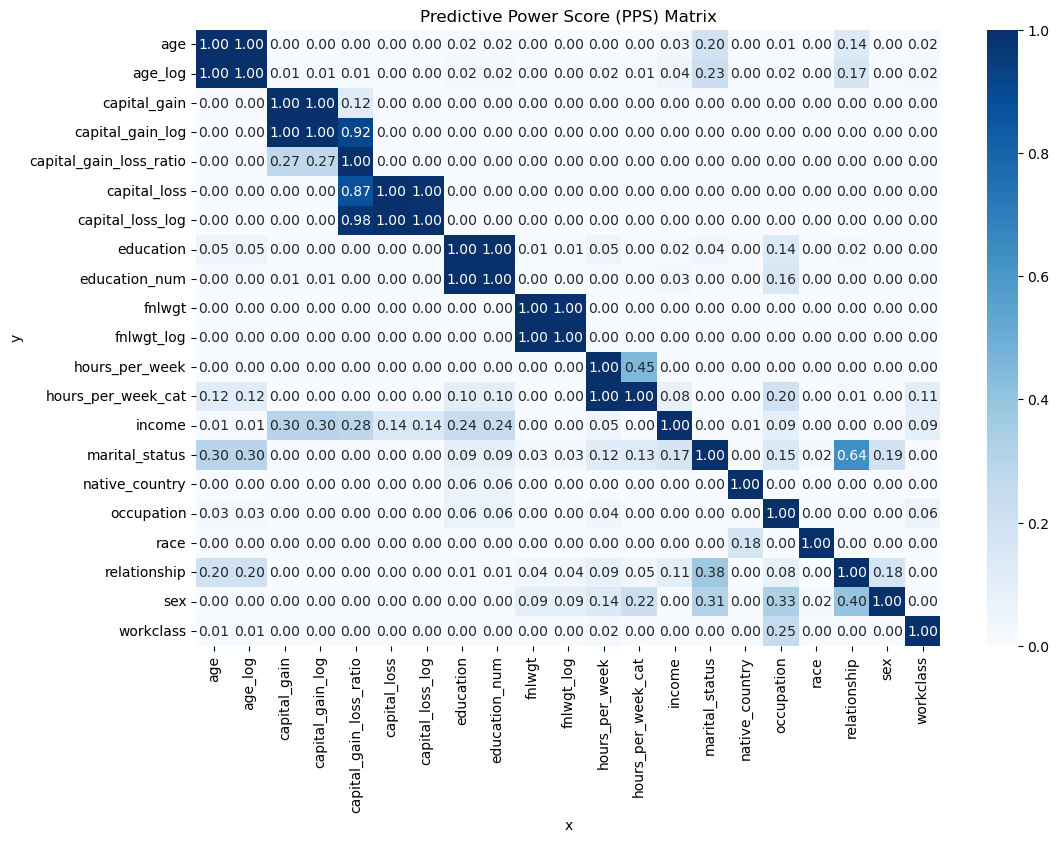

In [135]:
import ppscore as pps
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
pps_matrix = pps.matrix(df)[['x', 'y', 'ppscore']].pivot(columns='x', index='y', values='ppscore')


plt.figure(figsize=(12, 8))
sns.heatmap(pps_matrix, annot=True, cmap='Blues', fmt=".2f")
plt.title("Predictive Power Score (PPS) Matrix")
plt.show()


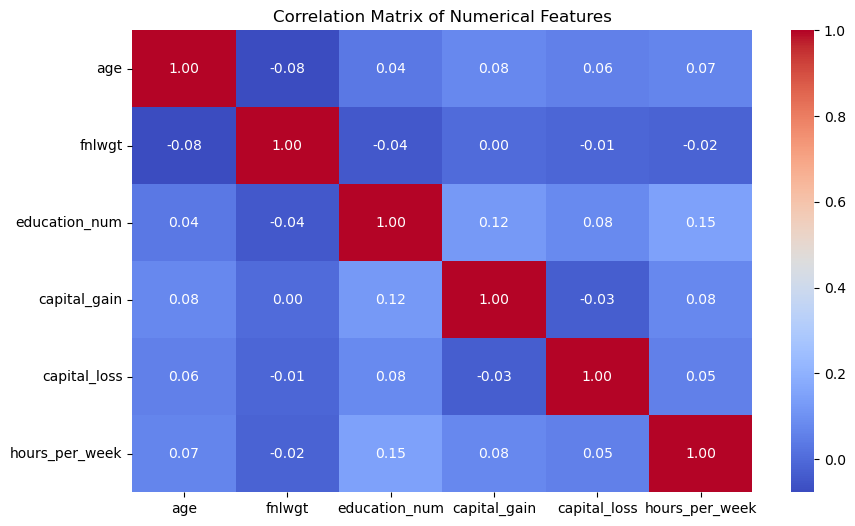

In [137]:
#Correlation matrix
correlation_matrix = numeric.corr()
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Numerical Features")
plt.show()

## Comparing PPS and Correlation:

- The Correlation matrix primarily highlights linear relationships between numerical features like age, fnlwgt, education_num, capital_gain, capital_loss, and hours_per_week. For example, you can see a moderate positive correlation between age and education_num, and a strong positive correlation between capital_gain and capital_loss.
- The PPS matrix provides a broader view, showing the predictive power between all features, including the categorical ones like workclass, education, marital_status, occupation, relationship, race, sex, native_country, and income. It can also capture non-linear relationships that the correlation matrix might miss.
  
## Relationships Observed from the PPS Matrix:

*Income:* The PPS matrix is particularly useful for understanding which features are good predictors of income. You can see that education_num, capital_gain, hours_per_week, and relationship have relatively higher predictive power for income compared to other features. This suggests these features are more strongly related to whether someone's income is above or below 50K.

*Occupation:* The PPS matrix also reveals that workclass and education have notable predictive power for occupation. This makes sense, as your education and type of work often influence your occupation.

*Relationship and Marital Status:* There's a strong predictive relationship between relationship and marital_status. This is expected, as someone's relationship status (e.g., Husband, Wife, Not-in-family) is directly tied to their marital status (e.g., Married-civ-spouse, Never-married, Divorced).

*Education and Education_num:* As expected, there is a very high predictive power between education (the categorical version) and education_num (the numerical representation). This confirms they essentially represent the same information.
